# WP5 — window and percentile sensitivity, and the robustness comparison

Reviewer major comment 5: *"…sensitivity analyses for key findings (e.g., the IFNA-L1
association, the SVA-termination association) using alternative window sizes (5 kb and
20 kb) and alternative percentiles (e.g., 10%)."*

Decision **D5** is the full version, plus *"a new notebook section comparing the original
results (hand-written scripts, 10 kb, 5 %) against the alternatives, with intersection,
robustness analysis and statistical tests"*. That comparison is section 6 onwards.

The enrichment numbers come from `05b_window_sensitivity.py` and the GO numbers from
`05c_percentile_sensitivity.py`; this notebook renders them and adds the three robustness
measures that need the per-gene tables: gene-set stability, rank stability, and the
headline-claim × condition table.

**Writes** `svg/S13A…S13E_*.svg` → new Supplementary Figure S13.

In [1]:
import gzip
import io
import json
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy import stats

sys.path.insert(0, os.path.abspath("."))
import revision_lib as rl

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({"font.size": rl.GLOBAL_FONT_SIZE})
os.makedirs(rl.SVG_DIR, exist_ok=True)

OUT = rl.OUTPUT_DIR
WINDOWS = ["5kb", "10kb", "20kb"]
WINDOW_COLOURS = {"5kb": "#9ecae1", "10kb": "#195f90", "20kb": "#08306b"}
PUBLISHED_WINDOW = "10kb"
RANDOM_SEED = 42

classes = pd.read_csv(os.path.join(OUT, "window_sensitivity_classes.csv"))
families = pd.read_csv(os.path.join(OUT, "window_sensitivity_families.csv"))
concordance = pd.read_csv(os.path.join(OUT, "window_sensitivity_concordance.csv"))
flips = pd.read_csv(os.path.join(OUT, "window_sensitivity_flips.csv"))
spans = json.load(open(os.path.join(OUT, "window_sensitivity_ntss.json")))
print({w: f"{v:,} bp" for w, v in spans.items()})

# Needed by S13A, S13B and S13C: every family-level row is coloured by the class it
# belongs to, so a reader moving between this figure and Figures 4-6 sees one
# colour convention. Not loaded by the first version of this notebook.
family_to_class = (
    pd.read_csv(os.path.join(rl.REPO_DIR, "families_by_classes_TE.csv"))
    .dropna().set_index("family_name")["class_name"].to_dict()
)
print(f"{len(family_to_class)} families mapped to a class")


def class_of(name, level):
    """The TE class colour key for a class-level or family-level row label."""
    return name if level == "class_name" else family_to_class.get(name, "")

{'5kb': '144,952,895 bp', '10kb': '272,233,268 bp', '20kb': '494,969,139 bp'}
44 families mapped to a class


## 1. Panel S13A — observed/random OR at each window size

The published column is 10 kb. Two things have to be visible at once: the **ranking** is
preserved across windows, and the **magnitude** is not — the fold change rises
monotonically with window width for almost every group. Both are reported; the second is
the honest finding the plan pre-committed to reporting if it appeared.

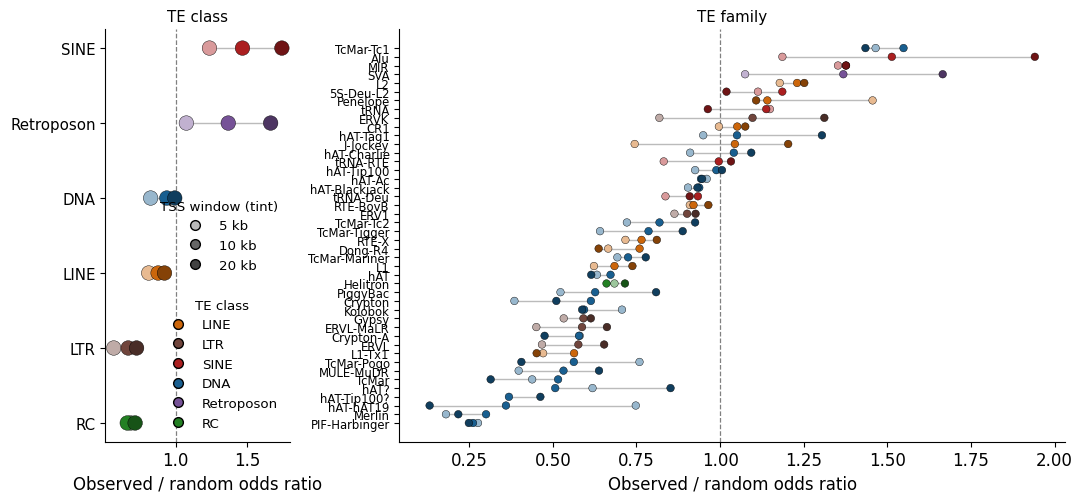

In [2]:
# The classes panel is deliberately narrow with large dots and the families panel wide
# with small ones, so the six classes read as the headline and the 44 families as the
# supporting detail. Hue encodes the TE class, tint encodes the TSS window.
fig, (ax_class, ax_family) = plt.subplots(
    1, 2, figsize=(11.0, 5.2), gridspec_kw={"width_ratios": [1, 3.6]}
)
DOT_SIZE = {"class_name": 110, "family_name": 30}

for ax, table, level, label in [
    (ax_class, classes, "class_name", "TE class"),
    (ax_family, families, "family_name", "TE family"),
]:
    wide = table.pivot(index=level, columns="window", values="or_observed_to_random")
    wide = wide.reindex(columns=[w for w in WINDOWS if w in wide.columns])
    order = wide[PUBLISHED_WINDOW].sort_values().index
    wide = wide.loc[order]
    positions = np.arange(len(order))

    for window in wide.columns:
        colours = [
            rl.shade(rl.CLASS_PALETTE.get(class_of(name, level), "#999999"),
                     rl.WINDOW_SHADES[window])
            for name in wide.index
        ]
        ax.scatter(wide[window], positions, s=DOT_SIZE[level], zorder=3,
                   color=colours, edgecolor="black", linewidth=0.3)
    for i, name in enumerate(order):
        values = wide.loc[name].dropna()
        ax.plot([values.min(), values.max()], [i, i], color="#bbbbbb", lw=1.0, zorder=2)

    ax.axvline(1.0, color="grey", ls="--", lw=0.9)
    ax.set_yticks(positions)
    ax.set_yticklabels(order, fontsize=rl.fs(7) if level == "family_name" else rl.fs(9))
    ax.set_xlabel("Observed / random odds ratio")
    ax.set_title(label, fontsize=rl.fs(9))
    ax.spines[["top", "right"]].set_visible(False)

# Two legend blocks: the hue is the TE class, the tint is the window. Grey swatches carry
# the tint scale so it reads as a third dimension rather than as three more classes.
class_handles = [
    Line2D([], [], marker="o", ls="", markersize=7, markerfacecolor=colour,
           markeredgecolor="black", label=name)
    for name, colour in rl.CLASS_PALETTE_SHORT.items()
]
window_handles = [
    Line2D([], [], marker="o", ls="", markersize=7,
           markerfacecolor=rl.shade("#666666", rl.WINDOW_SHADES[w]),
           markeredgecolor="black", label=f"{w[:-2]} kb")
    for w in WINDOWS
]
legend_classes = ax_class.legend(handles=class_handles, title="TE class", frameon=False,
                                 fontsize=rl.fs(8), title_fontsize=rl.fs(8),
                                 loc="lower right")
ax_class.add_artist(legend_classes)
ax_class.legend(handles=window_handles, title="TSS window (tint)", frameon=False,
                fontsize=rl.fs(8), title_fontsize=rl.fs(8), loc="center right")
fig.tight_layout()
fig.savefig(os.path.join(rl.SVG_DIR, "S13A_or_by_window.svg"),
            format="svg", transparent=True, bbox_inches="tight")
plt.show()

## 2. Panel S13B — Bland–Altman agreement between window pairs

Difference against mean, for the 44 families. The bias (mean difference) is the
scale-dependence of section 1 in one number; the limits of agreement show its spread.

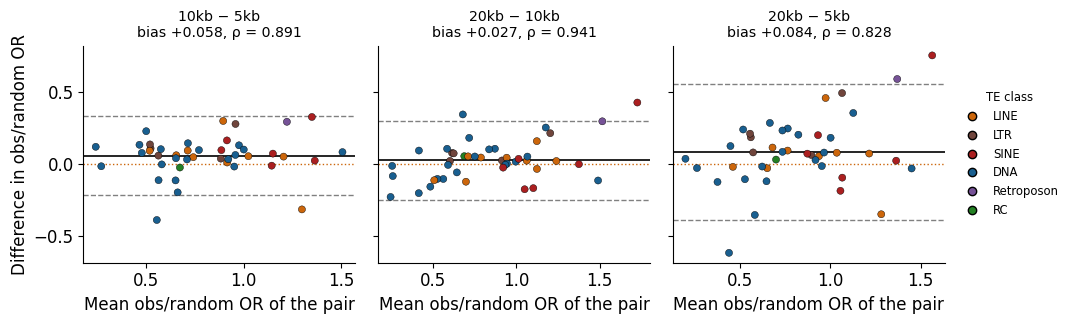

In [3]:
family_wide = families.pivot(index="family_name", columns="window",
                             values="or_observed_to_random")
pairs = [("5kb", "10kb"), ("10kb", "20kb"), ("5kb", "20kb")]

fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.4), sharey=True)
for ax, (w1, w2) in zip(axes, pairs):
    if w1 not in family_wide.columns or w2 not in family_wide.columns:
        continue
    pair = family_wide[[w1, w2]].dropna()
    mean_of_pair = pair.mean(axis=1).to_numpy()
    difference = (pair[w2] - pair[w1]).to_numpy()
    bias, sd = difference.mean(), difference.std(ddof=1)

    # One colour per TE class rather than one colour for all 44 families, so a
    # class-specific window effect is visible instead of averaged away.
    colours = [rl.CLASS_PALETTE.get(family_to_class.get(f, ""), "#cccccc")
               for f in pair.index]
    ax.scatter(mean_of_pair, difference, s=26, color=colours,
               edgecolor="black", linewidth=0.3, zorder=3)
    ax.axhline(bias, color="black", lw=1.2)
    ax.axhline(bias + 1.96 * sd, color="grey", ls="--", lw=1.0)
    ax.axhline(bias - 1.96 * sd, color="grey", ls="--", lw=1.0)
    ax.axhline(0, color="#cc660b", ls=":", lw=1.0)

    row = concordance[(concordance.level == "family_name")
                      & (concordance.window_a == w1) & (concordance.window_b == w2)]
    rho = float(row["spearman_rho"].iloc[0]) if len(row) else np.nan
    ax.set_title(f"{w2} − {w1}\nbias {bias:+.3f}, ρ = {rho:.3f}", fontsize=rl.fs(8.5))
    ax.set_xlabel("Mean obs/random OR of the pair")
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Difference in obs/random OR")
axes[-1].legend(
    handles=[Line2D([], [], marker="o", ls="", markersize=6, markerfacecolor=c,
                    markeredgecolor="black", label=n)
             for n, c in rl.CLASS_PALETTE_SHORT.items()],
    title="TE class", frameon=False, fontsize=rl.fs(7), title_fontsize=rl.fs(7),
    loc="center left", bbox_to_anchor=(1.02, 0.5),
)
fig.tight_layout()
fig.savefig(os.path.join(rl.SVG_DIR, "S13B_bland_altman_families.svg"),
            format="svg", transparent=True, bbox_inches="tight")
plt.show()

## 3. Concordance, as measured rather than eyeballed

Every pair carries a permutation test of its Spearman ρ against a label-shuffled null, so
"concordant" is a number. Significance flips are listed in full — 1 of 6 classes and 10 of
44 families, 9 of those 10 gaining significance at 20 kb, which is a power effect (20 kb
carries ~3.4× the observed elements of 5 kb).

In [4]:
print(concordance[["level", "window_a", "window_b", "n", "spearman_rho", "pearson_r",
                   "concordance_permutation_p", "bland_altman_mean_diff"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print(f"\nsignificance flips: {len(flips)}")
print(flips.to_string(index=False))

      level window_a window_b  n  spearman_rho  pearson_r  concordance_permutation_p  bland_altman_mean_diff
 class_name      5kb     10kb  6        0.9429      0.979                   0.008999                  0.1303
 class_name      5kb     20kb  6        0.9429     0.9664                   0.008099                  0.2615
 class_name     10kb     20kb  6             1     0.9953                     0.0015                  0.1312
family_name      5kb     10kb 43        0.8905     0.8987                  9.999e-05                 0.05841
family_name      5kb     20kb 43         0.828     0.7722                  9.999e-05                 0.08385
family_name     10kb     20kb 44        0.9412      0.934                  9.999e-05                 0.02699

significance flips: 11
      level    class_name  10kb  20kb   5kb
 class_name            RC False  True False
family_name          ERVL False  True  True
family_name         Gypsy False  True  True
family_name      Helitron False  True

## 4. Panel S13C — GO-term stability between the 5 % and 10 % gene-set cuts

Jaccard is deflated by *gains*: the wider cut has more genes and therefore more power, so
it finds more terms. The metric that answers the reviewer is the **fraction of published
(5 %) terms preserved at 10 %**, plotted on the right.

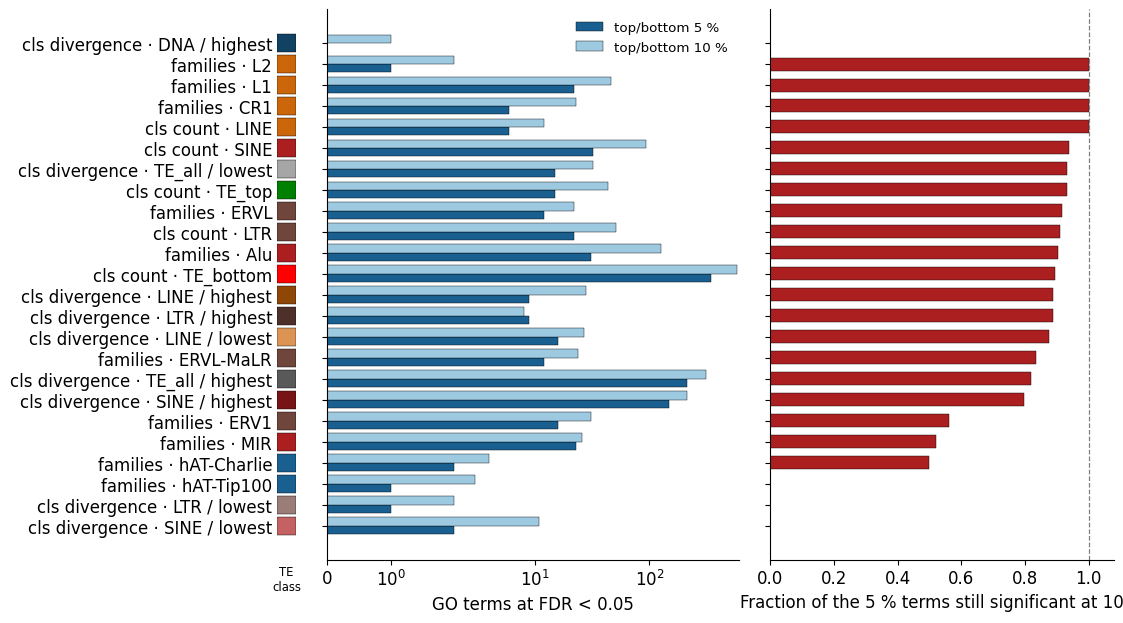

median fraction preserved: 0.889 (n = 24 percentile-dependent groups)


In [5]:
percentile_summary = pd.read_csv(os.path.join(OUT, "percentile_sensitivity_summary.csv"))
dependent = percentile_summary[
    percentile_summary["percentile_dependent"] & percentile_summary["foreground_changed"]
].copy()
dependent["label"] = dependent["level"].str.replace("classes_", "cls ", regex=False) \
                     + " · " + dependent["group"]
dependent = dependent.sort_values("fraction_of_5pct_preserved")


def row_annotation_colour(level, group):
    """Row colour matching the clustermap side annotations of Figures 4B / 5B / 6B.

    The three GO levels in this panel are annotated with the same colours their own
    main-text figure uses, so a reader can carry the class identity across figures
    instead of re-learning it here.
    """
    if level == "classes_count":                                        # as Figure 4B
        return rl.CLASS_PALETTE.get(group, "#cccccc")
    if level == "classes_divergence":                                   # as Figure 5B
        return rl.CLASS_PALETTE_DIVERGENCE.get(group.replace(" / ", "_"), "#cccccc")
    return rl.CLASS_PALETTE.get(family_to_class.get(group, ""), "#cccccc")   # as 6B


# A narrow axes to the left of the counts panel carries one coloured cell per row.
fig, (ax_annotation, ax_counts, ax_preserved) = plt.subplots(
    1, 3, figsize=(11.4, 6.4), sharey=True,
    gridspec_kw={"width_ratios": [0.055, 1.2, 1]},
)
positions = np.arange(len(dependent))

for i, row in enumerate(dependent.itertuples()):
    ax_annotation.barh(i, 1.0, height=0.86,
                       color=row_annotation_colour(row.level, row.group),
                       edgecolor="black", linewidth=0.3)
ax_annotation.set_xlim(0, 1)
ax_annotation.set_xticks([])
ax_annotation.set_xlabel("TE\nclass", fontsize=rl.fs(7))
for spine in ax_annotation.spines.values():
    spine.set_visible(False)
ax_annotation.tick_params(length=0)

ax_counts.barh(positions - 0.2, dependent["n_terms_5pct"], height=0.4,
               color="#195f90", edgecolor="black", linewidth=0.3, label="top/bottom 5 %")
ax_counts.barh(positions + 0.2, dependent["n_terms_10pct"], height=0.4,
               color="#9ecae1", edgecolor="black", linewidth=0.3, label="top/bottom 10 %")
ax_counts.set_yticks(positions)
ax_counts.set_yticklabels(dependent["label"], fontsize=rl.fs(7))
ax_counts.set_xlabel("GO terms at FDR < 0.05")
ax_counts.set_xscale("symlog")
ax_counts.legend(frameon=False, fontsize=rl.fs(8))
ax_counts.spines[["top", "right"]].set_visible(False)

ax_preserved.barh(positions, dependent["fraction_of_5pct_preserved"], height=0.62,
                  color="#ab1f20", edgecolor="black", linewidth=0.3)
ax_preserved.axvline(1.0, color="grey", ls="--", lw=0.9)
ax_preserved.set_xlim(0, 1.08)
ax_preserved.set_xlabel("Fraction of the 5 % terms still significant at 10 %")
ax_preserved.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(rl.SVG_DIR, "S13C_go_term_stability_percentile.svg"),
            format="svg", transparent=True, bbox_inches="tight")
plt.show()
print(f"median fraction preserved: "
      f"{dependent['fraction_of_5pct_preserved'].median():.3f} "
      f"(n = {len(dependent)} percentile-dependent groups)")

## 5. Panel S13D — the headline claims under all six conditions

One row per abstract-level claim, one column per condition: **3 TSS windows × 2 gene-set
percentiles**, not the two percentile columns this panel carried first (decision D-b). The four
window cells were `not evaluated` until `07b_go_grid.py` ran GO at 5 kb and 20 kb; the table is
read from `output/go_grid_headline_by_condition.csv`, so this panel and `nb07`'s S12 panels
cannot disagree.

A filled circle is significant at FDR < 0.05, and its **colour** is the FDR on the same
`coolwarm` −log10(FDR) scale the GO networks of Figures 4A, 5A and 6A use — via
`rl.go_fdr_norm`, so the shared scale is a named quantity rather than two conventions that
happen to look alike. An open circle is not significant or absent. Because colour now carries
the strength of the evidence, the legend is down to the one entry colour cannot express.

The published condition (10 kb / 5 %) is marked on the axis.

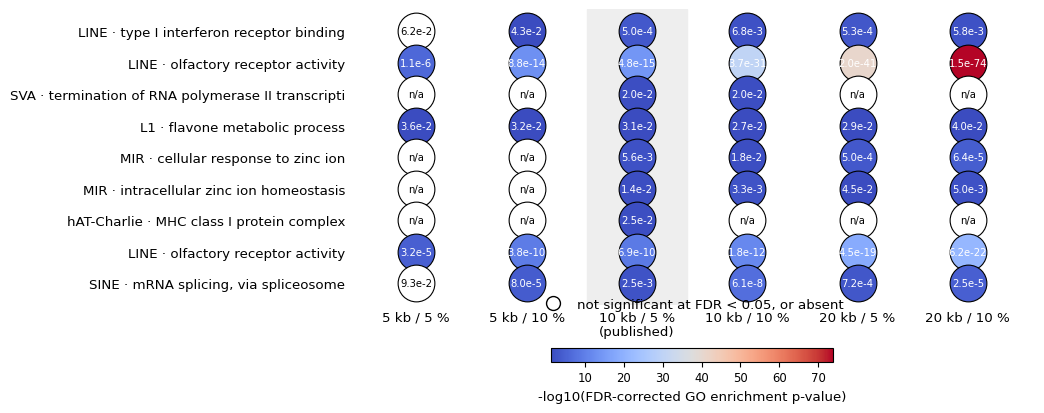

      group                                      term_name  n_conditions_survived               verdict
       LINE             type I interferon receptor binding                      5       survives 5 of 6
       LINE                    olfactory receptor activity                      6 robust across all six
        SVA termination of RNA polymerase II transcription                      2       survives 2 of 6
         L1                      flavone metabolic process                      6 robust across all six
        MIR                  cellular response to zinc ion                      4       survives 4 of 6
        MIR             intracellular zinc ion homeostasis                      4       survives 4 of 6
hAT-Charlie                    MHC class I protein complex                      1       survives 1 of 6
       LINE                    olfactory receptor activity                      6 robust across all six
       SINE                 mRNA splicing, via spliceosome      

In [6]:
headline = pd.read_csv(os.path.join(OUT, "go_grid_headline_by_condition.csv"))
headline["row_label"] = headline["group"] + " · " + headline["term_name"].str.slice(0, 44)

# Six conditions, not two: 3 windows x 2 percentiles.
CONDITIONS = [(w, p) for w in WINDOWS for p in (5, 10)]
PUBLISHED_CONDITION = (PUBLISHED_WINDOW, 5)

# One colour scale for every FDR shown here and in the GO networks. The floor is the
# publication threshold, so the palest filled circle is exactly FDR 0.05.
shown_fdr = [headline[f"fdr_{w}_p{p}"] for w, p in CONDITIONS]
all_fdr_values_shown = pd.concat(shown_fdr).dropna()
all_fdr_values_shown = all_fdr_values_shown[all_fdr_values_shown < rl.FDR_THRESHOLD]
norm = rl.go_fdr_norm(all_fdr_values_shown)
cmap = plt.get_cmap(rl.GO_FDR_CMAP)

fig, ax = plt.subplots(figsize=(10.6, 0.30 * len(headline) + 1.6))
for i, row in enumerate(headline.itertuples()):
    for j, (window, pct) in enumerate(CONDITIONS):
        survives = getattr(row, f"survives_{window}_p{pct}")
        fdr = getattr(row, f"fdr_{window}_p{pct}")
        ax.scatter(j, i, s=700,
                   color=cmap(norm(-np.log10(fdr))) if survives else "white",
                   edgecolor="black", linewidth=0.8, zorder=3)
        ax.text(j, i, "n/a" if pd.isna(fdr) else f"{fdr:.1e}".replace("e-0", "e-"),
                ha="center", va="center", fontsize=rl.fs(6),
                color="white" if survives else "black", zorder=4)

ax.set_yticks(range(len(headline)))
ax.set_yticklabels(headline["row_label"], fontsize=rl.fs(8))
ax.set_xticks(range(len(CONDITIONS)))
ax.set_xticklabels(
    [f"{w[:-2]} kb / {p} %" + ("\n(published)" if (w, p) == PUBLISHED_CONDITION else "")
     for w, p in CONDITIONS],
    fontsize=rl.fs(8),
)
ax.set_xlim(-0.6, len(CONDITIONS) - 0.4)
ax.set_ylim(-0.7, len(headline) - 0.3)
ax.invert_yaxis()
# Shade the published column so a reader can see which one the paper reports.
ax.axvspan(CONDITIONS.index(PUBLISHED_CONDITION) - 0.45,
           CONDITIONS.index(PUBLISHED_CONDITION) + 0.45, color="#eeeeee", zorder=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

bar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax,
                   orientation="horizontal", fraction=0.04, pad=0.12, shrink=0.5)
bar.set_label("-log10(FDR-corrected GO enrichment p-value)", fontsize=rl.fs(8))
bar.ax.tick_params(labelsize=rl.fs(7))

# Colour carries significance now, so the legend only has to explain its absence.
ax.legend(handles=[
    Line2D([], [], marker="o", ls="", markersize=10, markerfacecolor="white",
           markeredgecolor="black", label="not significant at FDR < 0.05, or absent"),
], frameon=False, fontsize=rl.fs(8), loc="lower center", bbox_to_anchor=(0.5, -0.06))
fig.tight_layout()
fig.savefig(os.path.join(rl.SVG_DIR, "S13D_headline_claims_by_condition.svg"),
            format="svg", transparent=True, bbox_inches="tight")
plt.show()

print(headline[["group", "term_name", "n_conditions_survived", "verdict"]]
      .to_string(index=False))
print(f"\nclaims robust across all six conditions: "
      f"{int((headline.n_conditions_survived == len(CONDITIONS)).sum())} of "
      f"{len(headline)}")

# The robustness comparison (D5)

## 6. Gene-set stability across windows

The published gene sets are the top 5 % of genes by TE count per class at 10 kb. If the
window size changed which genes those are, every GO result downstream would move. Measured
here with Jaccard, the overlap coefficient, and a hypergeometric p-value for each overlap
against chance.

In [7]:
def per_gene_counts(window):
    """Per-gene TE counts, total and per class, from the 05a per-gene intersection."""
    path = os.path.join(OUT, f"observed_TEs_by_gene_{window}.tsv.zst")
    raw = subprocess.run(["zstd", "-dc", path], capture_output=True, check=True).stdout
    frame = pd.read_csv(
        io.BytesIO(raw), sep="\t", header=None,
        names=["score", "subfamily_name", "family_name", "class_name", "Gene_name"],
    )
    total = frame.groupby("Gene_name").size().rename("TE_number")
    by_class = (frame.groupby(["Gene_name", "class_name"]).size()
                .unstack(fill_value=0))
    return pd.concat([total, by_class], axis=1)


gene_counts = {w: per_gene_counts(w) for w in WINDOWS}
for w, frame in gene_counts.items():
    print(f"{w:5s} {len(frame):,} genes with >= 1 TE, "
          f"{int(frame['TE_number'].sum()):,} intersections")

population = sorted(set().union(*[set(f.index) for f in gene_counts.values()]))
TOP_N = len(population) // 20
print(f"\npopulation {len(population):,} genes -> top 5 % = {TOP_N:,} genes per set")

5kb   28,110 genes with >= 1 TE, 293,652 intersections
10kb  28,506 genes with >= 1 TE, 582,540 intersections
20kb  28,630 genes with >= 1 TE, 1,157,235 intersections

population 28,630 genes -> top 5 % = 1,431 genes per set


In [8]:
def top_set(window, column):
    frame = gene_counts[window]
    if column not in frame.columns:
        return set()
    return set(frame[column].sort_values(ascending=False).index[:TOP_N])


levels = ["TE_number"] + [c for c in rl.CLASS_NAMES if c in gene_counts["10kb"].columns]
rows = []
for column in levels:
    for w1, w2 in pairs:
        a, b = top_set(w1, column), top_set(w2, column)
        if not a or not b:
            continue
        shared = len(a & b)
        # Hypergeometric: probability of >= this many shared by chance, drawing |b| genes
        # from the population when |a| are "successes".
        p_value = stats.hypergeom.sf(shared - 1, len(population), len(a), len(b))
        rows.append(
            {
                "set": column,
                "window_a": w1,
                "window_b": w2,
                "n_a": len(a),
                "n_b": len(b),
                "n_shared": shared,
                "expected_shared": len(a) * len(b) / len(population),
                "jaccard": shared / len(a | b),
                "overlap_coefficient": shared / min(len(a), len(b)),
                "hypergeometric_p": p_value,
            }
        )
geneset_stability = pd.DataFrame(rows)
geneset_stability.to_csv(os.path.join(OUT, "robustness_geneset_stability.csv"), index=False)
print(geneset_stability.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

       set window_a window_b  n_a  n_b  n_shared  expected_shared  jaccard  overlap_coefficient  hypergeometric_p
 TE_number      5kb     10kb 1431 1431      1146            71.53   0.6678               0.8008                 0
 TE_number     10kb     20kb 1431 1431      1213            71.53   0.7356               0.8477                 0
 TE_number      5kb     20kb 1431 1431      1031            71.53   0.5631               0.7205                 0
      LINE      5kb     10kb 1431 1431      1079            71.53   0.6052                0.754                 0
      LINE     10kb     20kb 1431 1431      1131            71.53   0.6534               0.7904                 0
      LINE      5kb     20kb 1431 1431       963            71.53   0.5071                0.673                 0
       LTR      5kb     10kb 1431 1431       855            71.53    0.426               0.5975                 0
       LTR     10kb     20kb 1431 1431       925            71.53   0.4775              

## 7. Rank stability — Kendall τ between gene rankings, with a bootstrap CI

Stronger than the gene-set overlap because it uses the whole ranking rather than a cut at
5 %. Computed on the genes present at both windows; the CI is a 200-resample bootstrap
over genes.

In [9]:
rng = np.random.default_rng(RANDOM_SEED)
N_BOOTSTRAP = 200
rows = []
for column in levels:
    for w1, w2 in pairs:
        f1, f2 = gene_counts[w1], gene_counts[w2]
        if column not in f1.columns or column not in f2.columns:
            continue
        common = f1.index.intersection(f2.index)
        x = f1.loc[common, column].to_numpy(dtype=float)
        y = f2.loc[common, column].to_numpy(dtype=float)
        tau = stats.kendalltau(x, y).statistic

        boot = np.empty(N_BOOTSTRAP)
        for b in range(N_BOOTSTRAP):
            pick = rng.integers(0, len(common), len(common))
            boot[b] = stats.kendalltau(x[pick], y[pick]).statistic
        rows.append(
            {
                "set": column,
                "window_a": w1,
                "window_b": w2,
                "n_genes": len(common),
                "kendall_tau": tau,
                "ci_lower_2.5": float(np.percentile(boot, 2.5)),
                "ci_upper_97.5": float(np.percentile(boot, 97.5)),
            }
        )
rank_stability = pd.DataFrame(rows)
rank_stability.to_csv(os.path.join(OUT, "robustness_rank_stability.csv"), index=False)
print(rank_stability.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

       set window_a window_b  n_genes  kendall_tau  ci_lower_2.5  ci_upper_97.5
 TE_number      5kb     10kb    28110       0.7421         0.738         0.7461
 TE_number     10kb     20kb    28506       0.7772        0.7738          0.781
 TE_number      5kb     20kb    28110       0.6095        0.6041         0.6152
      LINE      5kb     10kb    28110       0.7498        0.7462         0.7536
      LINE     10kb     20kb    28506       0.7415        0.7371         0.7451
      LINE      5kb     20kb    28110       0.6076        0.6018         0.6123
       LTR      5kb     10kb    28110       0.6946        0.6898            0.7
       LTR     10kb     20kb    28506       0.6981        0.6933         0.7029
       LTR      5kb     20kb    28110       0.5182        0.5123         0.5255
      SINE      5kb     10kb    28110       0.7426        0.7389         0.7461
      SINE     10kb     20kb    28506       0.7932          0.79          0.796
      SINE      5kb     20kb    28110   

## 8. Panel S13E — gene-set and rank stability together

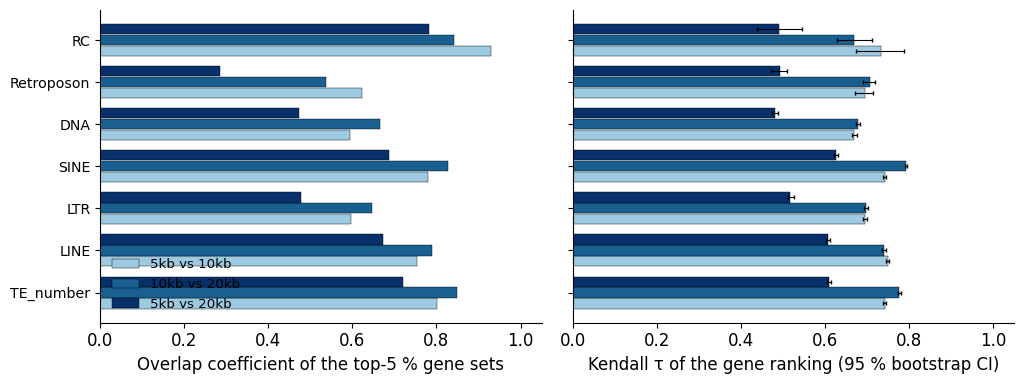

In [10]:
fig, (ax_jaccard, ax_tau) = plt.subplots(1, 2, figsize=(10.4, 4.0), sharey=True)
set_order = levels
positions = np.arange(len(set_order))
offsets = {p: (i - 1) * 0.26 for i, p in enumerate(pairs)}
pair_colours = {("5kb", "10kb"): "#9ecae1", ("10kb", "20kb"): "#195f90",
                ("5kb", "20kb"): "#08306b"}

for pair in pairs:
    sub = geneset_stability[(geneset_stability.window_a == pair[0])
                            & (geneset_stability.window_b == pair[1])]
    sub = sub.set_index("set").reindex(set_order)
    ax_jaccard.barh(positions + offsets[pair], sub["overlap_coefficient"], height=0.24,
                    color=pair_colours[pair], edgecolor="black", linewidth=0.3,
                    label=f"{pair[0]} vs {pair[1]}")

    sub_tau = rank_stability[(rank_stability.window_a == pair[0])
                             & (rank_stability.window_b == pair[1])]
    sub_tau = sub_tau.set_index("set").reindex(set_order)
    ax_tau.barh(positions + offsets[pair], sub_tau["kendall_tau"], height=0.24,
                color=pair_colours[pair], edgecolor="black", linewidth=0.3,
                xerr=[sub_tau["kendall_tau"] - sub_tau["ci_lower_2.5"],
                      sub_tau["ci_upper_97.5"] - sub_tau["kendall_tau"]],
                error_kw={"lw": 0.8, "capsize": 1.5})

ax_jaccard.set_yticks(positions)
ax_jaccard.set_yticklabels(set_order, fontsize=rl.fs(8.5))
ax_jaccard.set_xlabel("Overlap coefficient of the top-5 % gene sets")
ax_jaccard.set_xlim(0, 1.05)
ax_jaccard.legend(frameon=False, fontsize=rl.fs(8), loc="lower left")
ax_tau.set_xlabel("Kendall τ of the gene ranking (95 % bootstrap CI)")
ax_tau.set_xlim(0, 1.05)
for ax in (ax_jaccard, ax_tau):
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(rl.SVG_DIR, "S13E_geneset_and_rank_stability.svg"),
            format="svg", transparent=True, bbox_inches="tight")
plt.show()

## 9. Headline claim × condition table

Six conditions: 3 windows × 2 percentiles. What each condition can speak to differs, and the
table says so rather than leaving a blank to be misread:

* the **window** columns of the *enrichment* rows carry class- and family-level evidence from
  `05b_window_sensitivity.py`;
* the **GO** rows come from the GO grid, via `go_grid_headline_by_condition.csv`, which
  `nb07_go_grid_robustness.ipynb` writes from all six cells. Before `07b_go_grid.py` existed
  those cells read `not evaluated` — honest but narrow; the grid closed the gap.

This notebook is the **only** writer of `robustness_headline_claims_by_condition.csv`: it has
the full grid loaded by this point, so having nb07 also write the file would just mean whichever
notebook ran last decided its contents.

In [11]:
CLAIM_ROWS = [
    ("SINE enrichment near TSS", "enrichment", "class_name", "SINE"),
    ("SVA (Retroposon) enrichment near TSS", "enrichment", "class_name", "Retroposon"),
    ("LINE depletion near TSS", "enrichment", "class_name", "LINE"),
    ("Alu enrichment near TSS", "enrichment", "family_name", "Alu"),
    ("L1 depletion near TSS", "enrichment", "family_name", "L1"),
    ("SVA family enrichment near TSS", "enrichment", "family_name", "SVA"),
]

rows = []
for claim, kind, level, name in CLAIM_ROWS:
    table = classes if level == "class_name" else families
    record = {"claim": claim, "evidence": kind}
    for window in WINDOWS:
        hit = table[(table[level] == name) & (table["window"] == window)]
        if hit.empty:
            record[window] = "absent"
            continue
        row = hit.iloc[0]
        direction = "enriched" if row.or_observed_to_random > 1 else "depleted"
        record[window] = (f"{direction} {row.or_observed_to_random:.2f}x"
                          f"{'' if row.significant else ' (ns)'}")
    rows.append(record)

for row in headline.itertuples():
    # Every window column is real GO evidence now. The window columns report the published
    # 5 % percentile so they vary in one thing only; the percentile column holds the window
    # at 10 kb for the same reason.
    record = {"claim": f"{row.group}: {row.term_name}", "evidence": "GO"}
    for window in WINDOWS:
        survives = getattr(row, f"survives_{window}_p5")
        record[window] = ("survives" if survives else "lost") + " at 5 % genes"
    record["percentile_10"] = (
        ("survives" if getattr(row, f"survives_{PUBLISHED_WINDOW}_p10") else "lost")
        + " at 10 % genes"
    )
    record["n_conditions_survived"] = int(row.n_conditions_survived)
    rows.append(record)

claim_table = pd.DataFrame(rows)
claim_table.to_csv(os.path.join(OUT, "robustness_headline_claims_by_condition.csv"),
                   index=False)
assert not (claim_table == "not evaluated").any().any(), \
    "a condition is still unevaluated — run 07b_go_grid.py and nb07 first"
print(claim_table.to_string(index=False))

                                              claim   evidence                   5kb                  10kb                  20kb          percentile_10  n_conditions_survived
                           SINE enrichment near TSS enrichment        enriched 1.24x        enriched 1.47x        enriched 1.74x                    NaN                    NaN
               SVA (Retroposon) enrichment near TSS enrichment        enriched 1.07x        enriched 1.37x        enriched 1.67x                    NaN                    NaN
                            LINE depletion near TSS enrichment        depleted 0.81x        depleted 0.88x        depleted 0.92x                    NaN                    NaN
                            Alu enrichment near TSS enrichment        enriched 1.19x        enriched 1.51x        enriched 1.94x                    NaN                    NaN
                              L1 depletion near TSS enrichment        depleted 0.62x        depleted 0.68x        depleted 0.

## 10. What the robustness section concludes

Written out so the Results paragraph and the response letter quote the same sentences.

In [12]:
worst_rho = concordance["spearman_rho"].min()
worst_tau = rank_stability["kendall_tau"].min()
worst_overlap = geneset_stability["overlap_coefficient"].min()
max_hyper_p = geneset_stability["hypergeometric_p"].max()

print(f"""
Enrichment ranking     lowest Spearman rho across all window pairs and levels: {worst_rho:.3f}
                       (classes 10 vs 20 kb reaches 1.000; the weakest is families 5 vs 20 kb)
                       every concordance permutation test p <= {concordance['concordance_permutation_p'].max():.4f}
Gene sets              lowest overlap coefficient of the top-5 % sets: {worst_overlap:.3f}
                       largest hypergeometric p for any overlap: {max_hyper_p:.3g}
Gene ranking           lowest Kendall tau: {worst_tau:.3f}
GO terms (percentile)  median fraction of published terms preserved at 10 %: \
{dependent['fraction_of_5pct_preserved'].median():.3f}
Significance flips     {len(flips)} in total: 1 of 6 classes, 10 of 44 families,
                       9 of those 10 gaining significance at 20 kb (a power effect)
Scale dependence       obs/random OR rises monotonically with window width for almost every
                       group, so the DIRECTION of every headline claim is unchanged but its
                       EFFECT SIZE is scale-dependent. Reported, not smoothed over.
""")


Enrichment ranking     lowest Spearman rho across all window pairs and levels: 0.828
                       (classes 10 vs 20 kb reaches 1.000; the weakest is families 5 vs 20 kb)
                       every concordance permutation test p <= 0.0090
Gene sets              lowest overlap coefficient of the top-5 % sets: 0.285
                       largest hypergeometric p for any overlap: 3.53e-205
Gene ranking           lowest Kendall tau: 0.482
GO terms (percentile)  median fraction of published terms preserved at 10 %: 0.889
Significance flips     11 in total: 1 of 6 classes, 10 of 44 families,
                       9 of those 10 gaining significance at 20 kb (a power effect)
Scale dependence       obs/random OR rises monotonically with window width for almost every
                       group, so the DIRECTION of every headline claim is unchanged but its
                       EFFECT SIZE is scale-dependent. Reported, not smoothed over.



## 11. SVGs written

In [13]:
for name in sorted(os.listdir(rl.SVG_DIR)):
    if name.startswith("S13"):
        path = os.path.join(rl.SVG_DIR, name)
        print(f"  {name:48s} {os.path.getsize(path):>8,} B   -> new Supplementary Figure S13")

  S13A_or_by_window.svg                              86,551 B   -> new Supplementary Figure S13
  S13B_bland_altman_families.svg                     47,975 B   -> new Supplementary Figure S13
  S13C_go_term_stability_percentile.svg              55,780 B   -> new Supplementary Figure S13
  S13D_headline_claims_by_condition.svg              58,595 B   -> new Supplementary Figure S13
  S13D_headline_claims_by_percentile.svg             20,253 B   -> new Supplementary Figure S13
  S13E_geneset_and_rank_stability.svg                36,204 B   -> new Supplementary Figure S13
